# M-Pesa Statement Analysis — Future Work

This notebook implements the three items listed under **Future Work** in the README:

1. **Deeper spending categorization** — the cleaned dataset (`Sheet1`) collapses a lot of
   spending into broad, sometimes vague buckets (`other expenses`, `Personal Expenditures`,
   `airtime`). We recover the original M-Pesa transaction descriptions from `Table 10` and
   derive a `transaction_type` (Paybill, Merchant Payment, Peer Transfer, Small Business
   Payment, Agent Withdrawal, etc.) that gives a finer-grained view than the manual
   category labels alone.
2. **Predictive analysis** — a simple trend + moving-average forecast of monthly spending
   and balance, projected 3 months past the end of the current data.
3. **Year-over-year comparison (scaffolding)** — the data only covers July 2023–July 2024,
   so there is nothing to compare yet. This notebook defines a `year_over_year()` function
   that will work automatically once a second year of statements is appended to the source
   Excel file.


In [1]:
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("MPESA STATMENTSS.xlsx")


## 1. Load data

`Sheet1` is the cleaned, categorized dataset that feeds the Power BI dashboards. `Table 10` holds the original M-Pesa transaction descriptions before they were collapsed into categories.

In [2]:
sheet1 = pd.read_excel(DATA_PATH, sheet_name="Sheet1")
table10 = pd.read_excel(DATA_PATH, sheet_name="Table 10")

sheet1.columns = [c.strip().lower() for c in sheet1.columns]
table10.columns = [c.strip().lower() for c in table10.columns]

# Normalize categories: strip stray whitespace and fix casing so
# " transport" and "transport" (and "Personal Expenditures" vs "food") are consistent.
sheet1["category"] = sheet1["category"].astype(str).str.strip().str.lower()

print(sheet1.shape, table10.shape)
sheet1.head()


(2853, 5) (2958, 7)


,date,category,income,expenses,balance
0,2024-07-10,transaction cost,NaN,-7.0,403.17
1,2024-07-08,supermarket expenses,NaN,-285.0,390.17
2,2024-07-08,food,NaN,-60.0,675.17
3,2024-07-08,supermarket expenses,NaN,-60.0,465.17
4,2024-07-07,transaction cost,NaN,-7.0,580.17


## 2. Recover raw transaction descriptions

`Table 10` and `Sheet1` aren't in the same row order (Table 10 has ~100 extra rows,
likely transactions dropped during cleaning), so we can't join by row index. Instead we
join on `(date, withdrawn amount, balance)`, which is unique for ~97% of rows. The rest
are tagged `ambiguous` (same date/amount/balance appears more than once, e.g. two
identical transport top-ups on the same day) and left uncategorized rather than guessed.


In [3]:
def make_key(date, withdrawn, balance):
    w = round(withdrawn, 2) if pd.notna(withdrawn) else None
    b = round(balance, 2) if pd.notna(balance) else None
    return (date, w, b)

t10_map = defaultdict(list)
for _, r in table10.iterrows():
    t10_map[make_key(r["completion time"], r["withdrawn"], r["balance"])].append(r["details"])

def lookup(row):
    cands = t10_map.get(make_key(row["date"], row["expenses"], row["balance"]), [])
    if len(cands) == 1:
        return cands[0]
    if len(cands) > 1:
        return "AMBIGUOUS"
    return None

sheet1["raw_details"] = sheet1.apply(lookup, axis=1)
match_rate = (sheet1["raw_details"].notna() & (sheet1["raw_details"] != "AMBIGUOUS")).mean()
print(f"Recovered raw description for {match_rate:.1%} of rows")
sheet1["raw_details"].value_counts(dropna=False).head(10)


Recovered raw description for 93.1% of rows


raw_details
Airtime Purchase                                              287
Buy Bundles                                                   230
Funds received from - 07******177 FAITH CHERUIYOT             142
Customer Transfer of Funds Charge                             120
NaN                                                           103
AMBIGUOUS                                                      93
Pay Bill Online to 826915 - Safaricom Offers Acc. Ofa Moto     82
M-Shwari Withdraw                                              81
Merchant Payment to 493195 - THE ZOROS COMPANY                 71
Pay Bill Online to 826915 - Safaricom Offers Acc. Tunukiwa     70
Name: count, dtype: int64

## 3. Deeper spending categorization

M-Pesa transaction descriptions follow a small set of prefixes that map cleanly to a
*transaction type*, independent of who the merchant/recipient was:

| Prefix | Transaction type |
|---|---|
| `Pay Bill...` | Paybill / utility payment |
| `Merchant Payment...` | Merchant purchase |
| `Customer Transfer to...` | Peer-to-peer transfer |
| `Customer Payment to Small Business to...` | Small business payment |
| `Customer Withdrawal At Agent Till...` | Agent cash withdrawal |
| `Customer Transfer of Funds Charge` / `Pay Bill Charge` | Transaction cost |

This lets us break the vague `other expenses` (131 rows) and `personal expenditures` (59
rows) buckets down into what they actually were.


In [4]:
TYPE_RULES = [
    (r"^Pay Bill Charge", "Transaction Cost"),
    (r"^Customer Transfer of Funds Charge", "Transaction Cost"),
    (r"^Pay Bill", "Paybill / Utility Payment"),
    (r"^Merchant Payment", "Merchant Purchase"),
    (r"^Customer Payment to Small Business", "Small Business Payment"),
    (r"^Customer Transfer to", "Peer Transfer"),
    (r"^Customer Withdrawal At Agent Till", "Agent Cash Withdrawal"),
    (r"^Customer Deposit", "Cash Deposit"),
    (r"[Aa]irtime", "Airtime / Data"),
]

def classify(details):
    if not isinstance(details, str) or details == "AMBIGUOUS":
        return "Unclassified"
    for pattern, label in TYPE_RULES:
        if re.search(pattern, details):
            return label
    return "Other"

sheet1["transaction_type"] = sheet1["raw_details"].apply(classify)
sheet1["transaction_type"].value_counts()


transaction_type
Other                        776
Peer Transfer                596
Airtime / Data               352
Paybill / Utility Payment    331
Merchant Purchase            309
Unclassified                 196
Transaction Cost             145
Small Business Payment       121
Agent Cash Withdrawal         27
Name: count, dtype: int64

In [5]:
# Focus on the two catch-all categories the README calls out as too coarse
catchall = sheet1[sheet1["category"].isin(["other expenses", "personal expenditures"])]
breakdown = (
    catchall.groupby(["category", "transaction_type"])["expenses"]
    .agg(total_spent="sum", num_transactions="count")
    .sort_values("total_spent")
)
breakdown


total_spent  num_transactions
category              transaction_type                                        
personal expenditures Agent Cash Withdrawal         -11850.0                13
                      Peer Transfer                  -9657.0                24
                      Merchant Purchase              -9145.0                10
other expenses        Peer Transfer                  -4220.0                65
                      Merchant Purchase              -4070.0                20
                      Agent Cash Withdrawal          -2300.0                 4
personal expenditures Paybill / Utility Payment      -2060.0                 6
other expenses        Paybill / Utility Payment      -1420.0                16
                      Small Business Payment         -1350.0                23
personal expenditures Small Business Payment          -815.0                 4
                      Unclassified                    -510.0                 2
other expenses        Unclassified                    -250.0                 2
                      Transaction Cost                  -5.0                 1

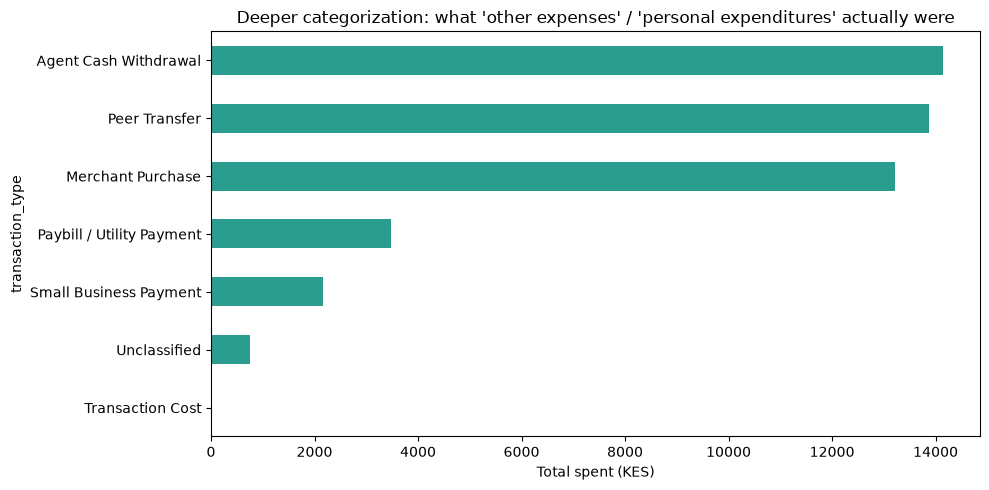

In [6]:
fig, ax = plt.subplots()
plot_df = (
    catchall.groupby("transaction_type")["expenses"].sum().abs().sort_values()
)
plot_df.plot.barh(ax=ax, color="#2a9d8f")
ax.set_xlabel("Total spent (KES)")
ax.set_title("Deeper categorization: what 'other expenses' / 'personal expenditures' actually were")
plt.tight_layout()
plt.show()


## 4. Overall spending by category (cleaned)

With normalized category labels (whitespace/casing fixed), here's the full spending breakdown.

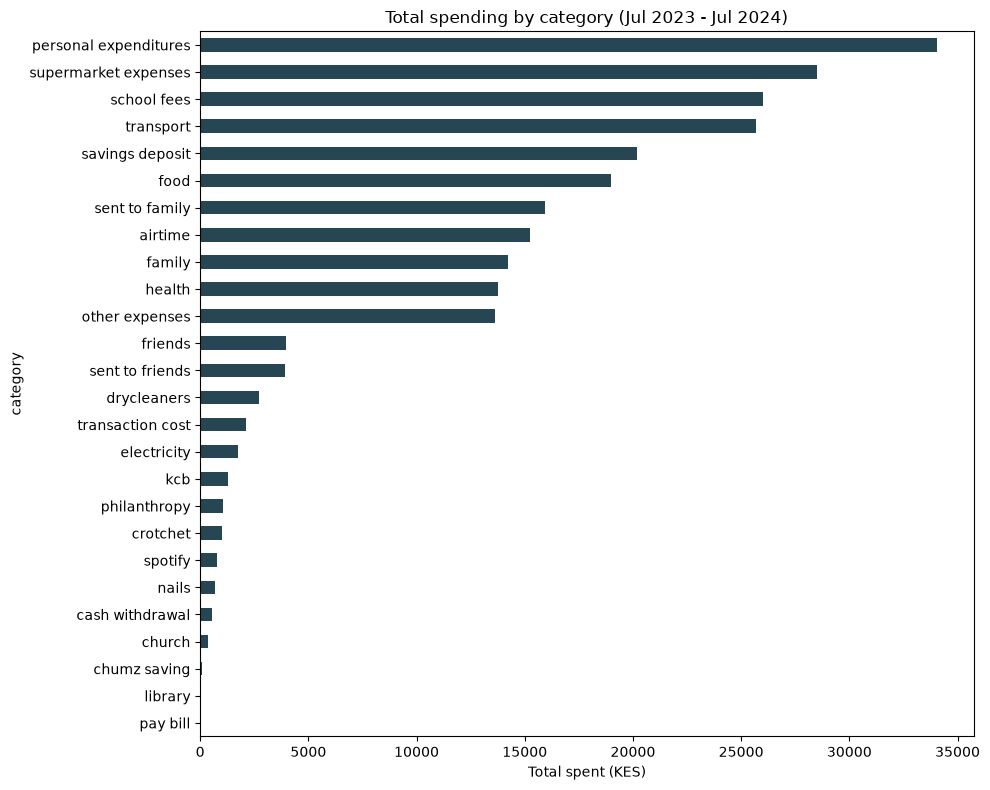

In [7]:
monthly_cat = sheet1.copy()
monthly_cat["month"] = pd.to_datetime(monthly_cat["date"]).dt.to_period("M")

spend_by_cat = (
    sheet1[sheet1["expenses"].notna()]
    .groupby("category")["expenses"]
    .sum()
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))
spend_by_cat.plot.barh(ax=ax, color="#264653")
ax.invert_yaxis()
ax.set_xlabel("Total spent (KES)")
ax.set_title("Total spending by category (Jul 2023 - Jul 2024)")
plt.tight_layout()
plt.show()


## 5. Predictive analysis

We aggregate to monthly totals and fit a simple linear trend on top of a 3-month moving
average to project the next 3 months of expenses and balance. With only 12 months of
history this is intentionally simple (a straight-line trend, not a seasonal model) —
it's meant to demonstrate the approach and can be swapped for a proper seasonal /
ARIMA model once more months of data are available.


In [8]:
monthly = (
    sheet1.assign(month=pd.to_datetime(sheet1["date"]).dt.to_period("M"))
    .groupby("month")
    .agg(income=("income", "sum"), expenses=("expenses", "sum"), balance=("balance", "last"))
    .sort_index()
)
monthly["expenses"] = monthly["expenses"].abs()
monthly


,income,expenses,balance
month,,,
2023-07,7650.0,7285.00,34.61
2023-08,18257.0,16167.00,489.61
2023-09,16940.0,19538.00,2629.61
2023-10,13399.0,13152.00,141.61
2023-11,16563.0,16749.00,263.61
2023-12,64810.0,65039.00,217.61
2024-01,35977.0,31805.00,289.61
2024-02,16629.0,20453.22,84.61
2024-03,11553.0,10157.00,92.39


In [9]:
def forecast_series(series, periods=3):
    """Linear-trend forecast with a fitted line over the historical months."""
    x = np.arange(len(series))
    y = series.values.astype(float)
    slope, intercept = np.polyfit(x, y, 1)
    fitted = slope * x + intercept

    future_x = np.arange(len(series), len(series) + periods)
    future_y = slope * future_x + intercept
    future_index = pd.period_range(series.index[-1] + 1, periods=periods, freq="M")

    fitted_series = pd.Series(fitted, index=series.index)
    forecast = pd.Series(future_y, index=future_index)
    return fitted_series, forecast

exp_fitted, exp_forecast = forecast_series(monthly["expenses"])
bal_fitted, bal_forecast = forecast_series(monthly["balance"])

print("Forecasted expenses (next 3 months):")
print(exp_forecast.round(0))
print("\nForecasted balance (next 3 months):")
print(bal_forecast.round(0))


Forecasted expenses (next 3 months):
2024-08    14974.0
2024-09    14404.0
2024-10    13833.0
Freq: M, dtype: float64

Forecasted balance (next 3 months):
2024-08    444.0
2024-09    433.0
2024-10    423.0
Freq: M, dtype: float64


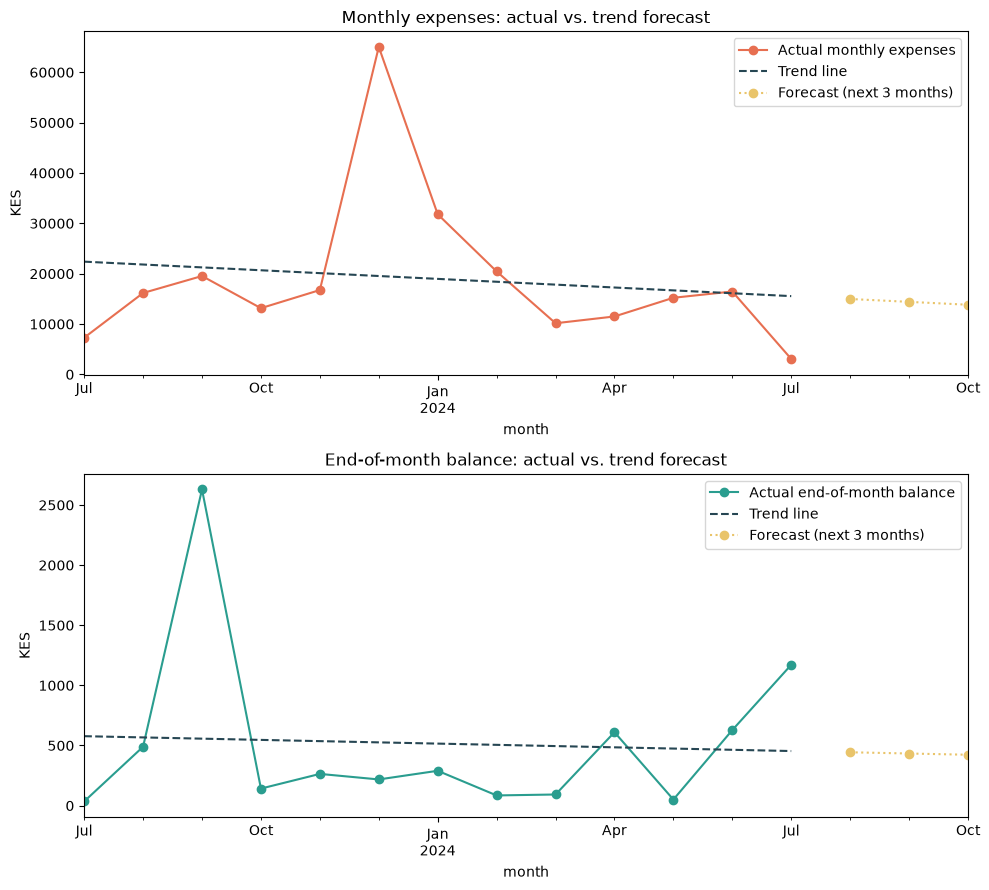

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=False)

ax = axes[0]
monthly["expenses"].plot(ax=ax, marker="o", label="Actual monthly expenses", color="#e76f51")
exp_fitted.plot(ax=ax, linestyle="--", label="Trend line", color="#264653")
exp_forecast.plot(ax=ax, marker="o", linestyle=":", label="Forecast (next 3 months)", color="#e9c46a")
ax.set_title("Monthly expenses: actual vs. trend forecast")
ax.set_ylabel("KES")
ax.legend()

ax = axes[1]
monthly["balance"].plot(ax=ax, marker="o", label="Actual end-of-month balance", color="#2a9d8f")
bal_fitted.plot(ax=ax, linestyle="--", label="Trend line", color="#264653")
bal_forecast.plot(ax=ax, marker="o", linestyle=":", label="Forecast (next 3 months)", color="#e9c46a")
ax.set_title("End-of-month balance: actual vs. trend forecast")
ax.set_ylabel("KES")
ax.legend()

plt.tight_layout()
plt.show()


## 6. Year-over-year comparison (scaffolding)

The data covers July 2023 – July 2024: a rolling 12-month window that happens to touch
two calendar years, not two full years. Pivoting by calendar year (below) shows that
only **July** has data in both 2023 and 2024 — every other month exists in just one of
the two columns, so there isn't yet a real month-by-month year-over-year comparison to
draw. This is a data limitation, not something more code can fix.

The `year_over_year()` function is ready to use as-is: once a second full year of
statements is appended to `Sheet1` in the source workbook, every month will have two
comparable values and re-running this cell will produce a real chart without any code
changes.


In [11]:
def year_over_year(df, value_col="expenses", agg="sum"):
    """Pivot monthly totals by year so each column is one year's Jan-Dec series.

    Works with any number of years; with a single year of data (current state)
    it simply returns a one-column table.
    """
    d = df.copy()
    d["year"] = pd.to_datetime(d["date"]).dt.year
    d["month_num"] = pd.to_datetime(d["date"]).dt.month
    pivot = d.pivot_table(index="month_num", columns="year", values=value_col, aggfunc=agg)
    pivot.index = pivot.index.map(lambda m: pd.Timestamp(2000, m, 1).strftime("%b"))
    return pivot

yoy_expenses = year_over_year(sheet1, value_col="expenses", agg=lambda s: s.abs().sum())
print(f"Years present in data: {sorted(pd.to_datetime(sheet1['date']).dt.year.unique())}")
yoy_expenses


Years present in data: [np.int32(2023), np.int32(2024)]


year,2023,2024
month_num,,
Jan,NaN,31805.00
Feb,NaN,20453.22
Mar,NaN,10157.00
Apr,NaN,11503.00
May,NaN,15215.22
Jun,NaN,16462.00
Jul,7285.0,3066.00
Aug,16167.0,NaN
Sep,19538.0,NaN


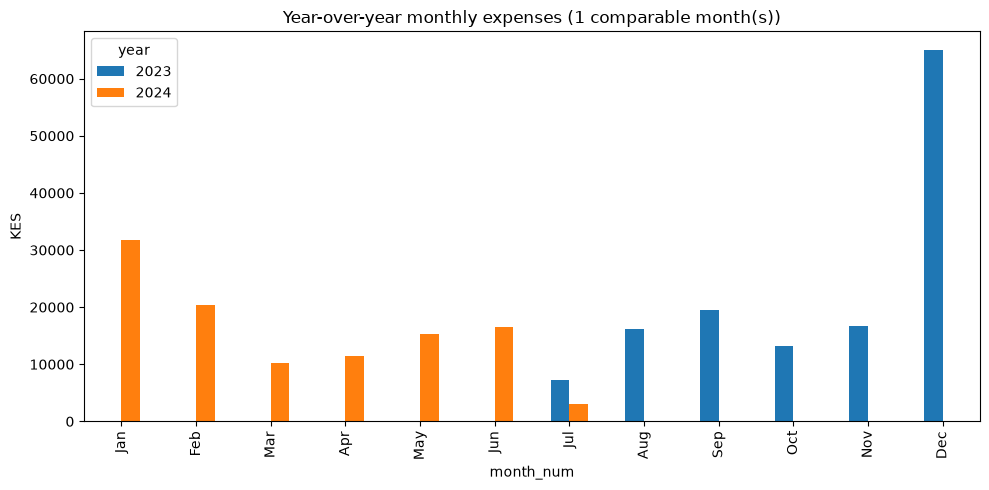

In [12]:
months_with_overlap = (yoy_expenses.notna().sum(axis=1) >= 2).sum()

if months_with_overlap > 0:
    yoy_expenses.plot.bar(ax=plt.gca())
    plt.title(f"Year-over-year monthly expenses ({months_with_overlap} comparable month(s))")
    plt.ylabel("KES")
    plt.tight_layout()
    plt.show()
else:
    print(
        "No calendar month currently has data in more than one year, so there's "
        "nothing to compare yet. Append a second full year of statements to Sheet1 "
        "and re-run this cell — year_over_year() will pick it up automatically."
    )


## 7. Export cleaned & re-categorized dataset

Writes the cleaned categories plus the new `transaction_type` column back out as a CSV
so it can be brought into Power BI as an updated data source for the dashboards.


In [13]:
out_path = Path("cleaned_categorized_transactions.csv")
sheet1.drop(columns=["raw_details"]).to_csv(out_path, index=False)
print(f"Wrote {len(sheet1)} rows to {out_path}")


Wrote 2853 rows to cleaned_categorized_transactions.csv
